In [331]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print("done")

done


### Generating Random Data

In [333]:
np.random.seed(0)
samples_per_cluster = 250

In [334]:
#Mean and Covarinace for each clusters:
mu1 = [2, 2]
mu2 = [5, 5]
mu3 = [-2, -2]
mu4 = [-4, 8]

sigma1 = [[0.9, -0.0255], [-0.0255, 0.9]]
sigma2 = [[0.5, 0], [0, 0.3]]
sigma3 = [[1, 0], [0, 0.9]]
sigma4 = [[0.8, 0], [0, 0.6]]

In [335]:
# Generate synthetic data 
data1 = np.random.multivariate_normal(mu1, sigma1, samples_per_cluster)
data2 = np.random.multivariate_normal(mu2, sigma2, samples_per_cluster)
data3 = np.random.multivariate_normal(mu3, sigma3, samples_per_cluster)
data4 = np.random.multivariate_normal(mu4, sigma4, samples_per_cluster)

X = np.vstack((data1, data2, data3, data4))

### WCSS Code:

In [337]:
# Step 5: Initiate WCSS and find optimal K via Elbow Method
wcss = []
k_range = range(1, 21)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=0, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Step 6: Perform K-Means Clustering with optimal K=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=0, n_init=10)
y_kmeans = kmeans_final.fit_predict(X)

### Visualization:

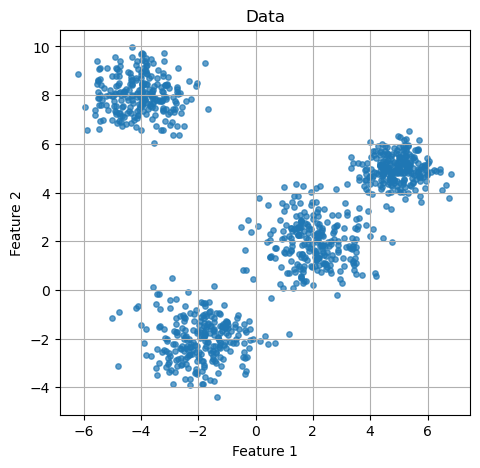

In [356]:
plt.figure(figsize=(18, 5))

# Plot A: Data Plot
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], s=15, alpha=0.7)
plt.title('Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)

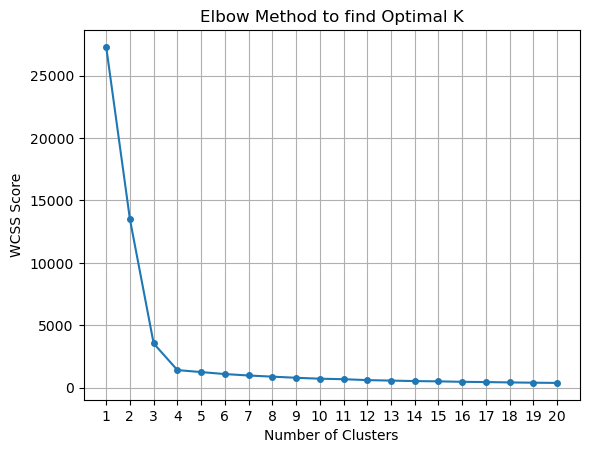

In [358]:
plt.plot(k_range, wcss, marker='o', markersize=4)
plt.title('Elbow Method to find Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS Score')
plt.xticks(k_range)
plt.grid(True)

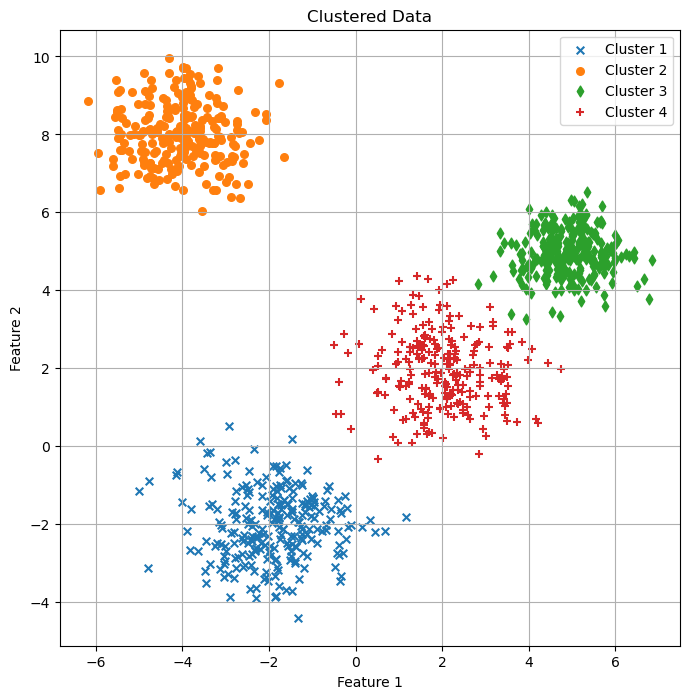

In [341]:
plt.figure(figsize=(8, 8))

markers = ['x', 'o', 'd', '+']
colors = ['C0', 'C1', 'C2', 'C3']

for i in range(4):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], 
                s=30, c=colors[i], marker=markers[i], label=f'Cluster {i+1}')

plt.title('Clustered Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## Report:

### Q1: What might happen if the value of the number of clusters is set too high or too low in KMeans?
K too low: Distinct data groups get merged, leading to underfitting and poor clustering.  
K too high: Natural clusters get split into many small clusters, leading to overfitting and capturing noise.


### Q2:What is the effect of initializing centroids far apart or too close together in K-Means, and how might this affect the final clustering?
If centroids are initialised too close together, they may converge to the same region, causing overlapping or ineffective clusters and poor separation of data points.
If centroids are initialised too far apart,they start in different regions of the data space and cover different types of data. This leads to faster convergence and results in more meaningful and well-separated final clusters.
Both scenarios can lead to local optima

### Q3:Centroid initialisation can be optimised using K-Means++, which selects initial centroids that are well spread out, reducing poor clustering and improving convergence.
Better clustering can be achieved by choosing initial centroids that are far apart, such as using K-Means++.
Running K-Means several times with different starting points and selecting the best result also improves the final clustering

### Q4:Why might the Elbow Method not always provide a clear solution for choosing the optimal number of clusters?
The Elbow Method may not always give a clear answer because the WCSS curve sometimes decreases smoothly without a sharp bend.
This makes it difficult to clearly identify the optimal number of clusters

### Q5: How can WCSS be influenced by the presence of outliers or noise in the data?
Outliers or noise can significantly increase WCSS(calculated using square distance) because they are far away from the cluster centroids.This can negatively affect the clustering results, as K-Means may shift centroids to reduce the impact of these extreme data points